In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.datasets import load_wine

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score

from sklearn.metrics import confusion_matrix,classification_report

from sklearn.model_selection import GridSearchCV

In [45]:
df=load_wine(as_frame=True).frame

df

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0,2
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0,2
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0,2
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0,2


In [46]:
display(df.isnull().sum())
display(df.duplicated().sum())

,0
alcohol,0
malic_acid,0
ash,0
alcalinity_of_ash,0
magnesium,0
total_phenols,0
flavanoids,0
nonflavanoid_phenols,0
proanthocyanins,0
color_intensity,0


np.int64(0)

<Axes: xlabel='target', ylabel='count'>

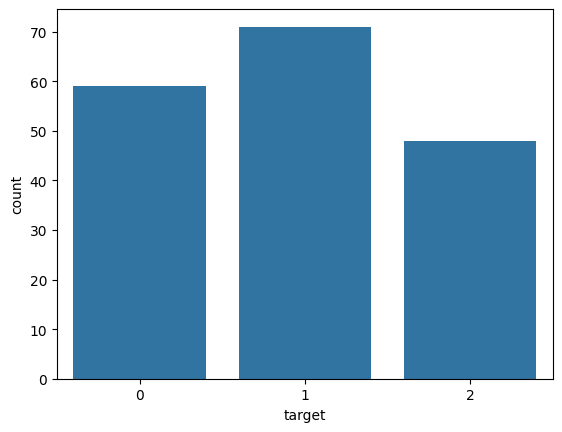

In [47]:
sns.countplot(data= df , x='target')

<Axes: >

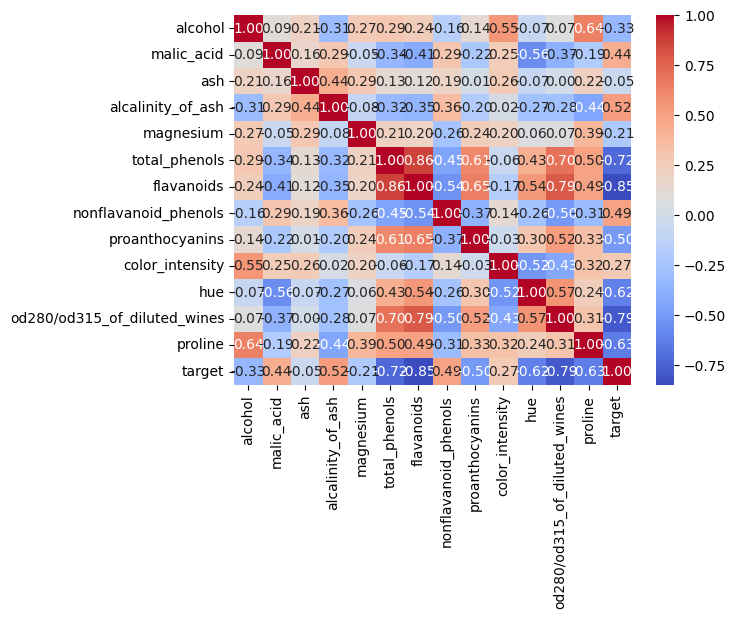

In [48]:
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm',fmt='.2f')

In [49]:
X=df.drop('target',axis=1)
y=df['target']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)

In [50]:
knn=Pipeline(
    steps=[
        ('scaler',StandardScaler()),
        ('model',KNeighborsClassifier(n_neighbors=15,metric='minkowski',p=2))
    ]
)

knn.fit(X_train,y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', KNeighborsClassifier(n_neighbors=15))])

In [51]:
y_pred=knn.predict(X_test)
y_pred

array([0, 2, 0, 1, 1, 0, 0, 1, 1, 2, 1, 2, 0, 2, 0, 1, 1, 0, 1, 0, 1, 1,
       0, 0, 1, 1, 0, 2, 1, 2, 0, 2, 1, 2, 2, 2])

In [52]:
accuracy = accuracy_score(y_test,y_pred)
print(accuracy)

1.0


In [53]:
conf_mat=confusion_matrix(y_test,y_pred)

conf_mat

array([[12,  0,  0],
       [ 0, 14,  0],
       [ 0,  0, 10]])

In [54]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



## changing k and testing the performance

In [55]:
performance=[]
acc=[]

for k in range(1,30):
  knn=Pipeline(
    steps=[
        ('scaler',StandardScaler()),
        ('model',KNeighborsClassifier(n_neighbors=k,metric='minkowski',p=2))
    ]
  )

  knn.fit(X_train,y_train)
  y_pred=knn.predict(X_test)
  accuracy=accuracy_score(y_test,y_pred)
  precision=precision_score(y_test,y_pred,average='weighted')
  recall=recall_score(y_test,y_pred,average='weighted')

  acc.append(accuracy)
  performance.append((k,(accuracy,precision,recall)))



In [56]:
print(performance)

[(1, (0.9722222222222222, 0.9743589743589745, 0.9722222222222222)), (2, (0.9444444444444444, 0.9523809523809523, 0.9444444444444444)), (3, (0.9722222222222222, 0.9743589743589745, 0.9722222222222222)), (4, (0.9444444444444444, 0.9465811965811967, 0.9444444444444444)), (5, (0.9722222222222222, 0.9747474747474748, 0.9722222222222222)), (6, (0.9722222222222222, 0.974074074074074, 0.9722222222222222)), (7, (1.0, 1.0, 1.0)), (8, (1.0, 1.0, 1.0)), (9, (1.0, 1.0, 1.0)), (10, (1.0, 1.0, 1.0)), (11, (1.0, 1.0, 1.0)), (12, (1.0, 1.0, 1.0)), (13, (1.0, 1.0, 1.0)), (14, (0.9722222222222222, 0.9743589743589745, 0.9722222222222222)), (15, (1.0, 1.0, 1.0)), (16, (1.0, 1.0, 1.0)), (17, (1.0, 1.0, 1.0)), (18, (0.9722222222222222, 0.9743589743589745, 0.9722222222222222)), (19, (1.0, 1.0, 1.0)), (20, (1.0, 1.0, 1.0)), (21, (1.0, 1.0, 1.0)), (22, (1.0, 1.0, 1.0)), (23, (1.0, 1.0, 1.0)), (24, (1.0, 1.0, 1.0)), (25, (1.0, 1.0, 1.0)), (26, (1.0, 1.0, 1.0)), (27, (1.0, 1.0, 1.0)), (28, (0.9722222222222222, 0.

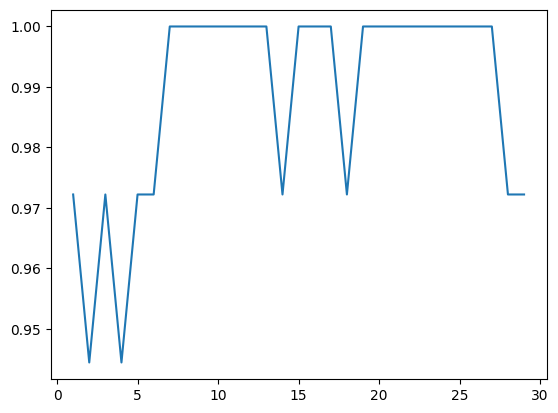

In [57]:
plt.plot(range(1,30),acc)

In [58]:
performance=[]
acc=[]

for k in range(1,30):
  knn=Pipeline(
    steps=[
        ('scaler',StandardScaler()),
        ('model',KNeighborsClassifier(n_neighbors=k,metric='minkowski',p=1))
    ]
  )

  knn.fit(X_train,y_train)
  y_pred=knn.predict(X_test)
  accuracy=accuracy_score(y_test,y_pred)
  precision=precision_score(y_test,y_pred,average='weighted')
  recall=recall_score(y_test,y_pred,average='weighted')

  acc.append(accuracy)
  performance.append((k,(accuracy,precision,recall)))



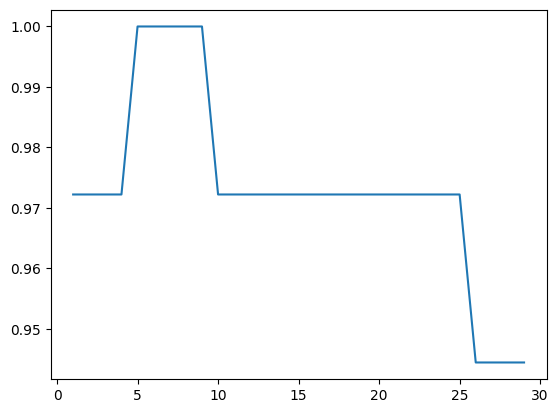

In [59]:
plt.plot(range(1,30),acc)

# Hyper parameter tunning using GridSearchCV

In [62]:
knn_model=Pipeline(
    steps=[
        ('scaler',StandardScaler()),
        ('knn',KNeighborsClassifier())
    ]
)

knn_model.fit(X_train,y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('knn', KNeighborsClassifier(n_neighbors=15))])

In [64]:
grid={
    "knn__n_neighbors":range(1,30),
    "knn__weights":['uniform','distance'],
    "knn__p":[1,2]
}

grid_search=GridSearchCV(
    estimator=knn_model,
    param_grid=grid,
    cv=5
)

grid_search.fit(X_train,y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('knn',
                                        KNeighborsClassifier(n_neighbors=15))]),
             param_grid={'knn__n_neighbors': range(1, 30), 'knn__p': [1, 2],
                         'knn__weights': ['uniform', 'distance']})

In [65]:
grid_search.best_params_

{'knn__n_neighbors': 8, 'knn__p': 1, 'knn__weights': 'uniform'}

In [66]:
grid_search.best_estimator_

Pipeline(steps=[('scaler', StandardScaler()),
                ('knn', KNeighborsClassifier(n_neighbors=8, p=1))])

In [67]:
model = grid_search.best_estimator_

y_pred= model.predict(X_test)

In [68]:
accuracy = accuracy_score(y_test,y_pred)
print(accuracy)

1.0
